# Optimization Results Analysis
## Cinema Showtime Schedule Optimization

This notebook analyzes the results from the mixed-integer optimization model for movie scheduling.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

# Set figure defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Load Data

In [35]:
# Load results files
results_dir = Path('results')

schedule_df = pd.read_csv(results_dir / 'baseline_schedule.csv')
summary_df = pd.read_csv(results_dir / 'baseline_summary.csv')
realized_df = pd.read_csv(results_dir / 'baseline_realized.csv')
demand_df = pd.read_csv(results_dir / 'demand_data.csv')
parameters_df = pd.read_csv(results_dir / 'baseline_parameters.csv')

# Load full dataset to get movie titles
# Movie IDs in results correspond to indices in this dataset
full_data_path = Path('../data/cleaned/final_merged_dataset_with_genres.csv')
full_df = pd.read_csv(full_data_path)

# Create movie metadata dataframe
# Movie IDs correspond to row indices in the full dataset
movie_df = pd.DataFrame({
    'movie_id': range(len(full_df)),
    'title': full_df['title'].values,
    'runtime': full_df['runtime'].values if 'runtime' in full_df.columns else None
})

# Filter to only movies in our results
result_movie_ids = pd.concat([
    schedule_df['movie_id'],
    demand_df['movie_id'],
    realized_df['movie_id']
]).unique()
movie_df = movie_df[movie_df['movie_id'].isin(result_movie_ids)]

print("Data loaded successfully!")
print(f"\nSchedule shape: {schedule_df.shape}")
print(f"Realized shape: {realized_df.shape}")
print(f"Demand shape: {demand_df.shape}")
print(f"Movies in results: {len(movie_df)}")
print(f"\nMovie titles loaded from: {full_data_path}")

Data loaded successfully!

Schedule shape: (98, 4)
Realized shape: (98, 5)
Demand shape: (98, 3)
Movies in results: 14

Movie titles loaded from: ../data/cleaned/final_merged_dataset_with_genres.csv


In [36]:
# Display summary metrics
summary_df.set_index('metric', inplace=True)
print("\n" + "="*50)
print("OPTIMIZATION SUMMARY")
print("="*50)
for metric, value in summary_df['value'].items():
    if metric == 'total_revenue':
        print(f"{metric:30s}: ${value:,.2f}")
    elif metric == 'capacity_utilization':
        print(f"{metric:30s}: {value:.1%}")
    else:
        print(f"{metric:30s}: {value:,.2f}")


OPTIMIZATION SUMMARY
total_revenue                 : $91,732.85
total_showings                : 98.00
total_tickets_sold            : 6,115.52
num_movies_scheduled          : 98.00
num_screens_used              : 8.00
avg_showings_per_movie        : 7.00
avg_tickets_per_showing       : 62.40
capacity_utilization          : 29.7%


## 2. Schedule Visualization

In [37]:
# Merge schedule with movie metadata
schedule_with_movies = schedule_df.merge(
    movie_df[['movie_id', 'title', 'runtime']], 
    on='movie_id', 
    how='left'
)

schedule_with_movies.head(10)

,movie_id,day,screen,showings,title,runtime
0,3664,Mon,Screen_2,1,The Smashing Machine,93.0
1,3664,Tue,Screen_2,1,The Smashing Machine,93.0
2,3664,Wed,Screen_3,1,The Smashing Machine,93.0
3,3664,Thu,Screen_3,1,The Smashing Machine,93.0
4,3664,Fri,Screen_19,1,The Smashing Machine,93.0
5,3664,Sat,Screen_19,1,The Smashing Machine,93.0
6,3664,Sun,Screen_19,1,The Smashing Machine,93.0
7,3488,Mon,Screen_3,1,The Mastermind,110.0
8,3488,Tue,Screen_5,1,The Mastermind,110.0
9,3488,Wed,Screen_3,1,The Mastermind,110.0


### 2.2 Screen Utilization Heatmap

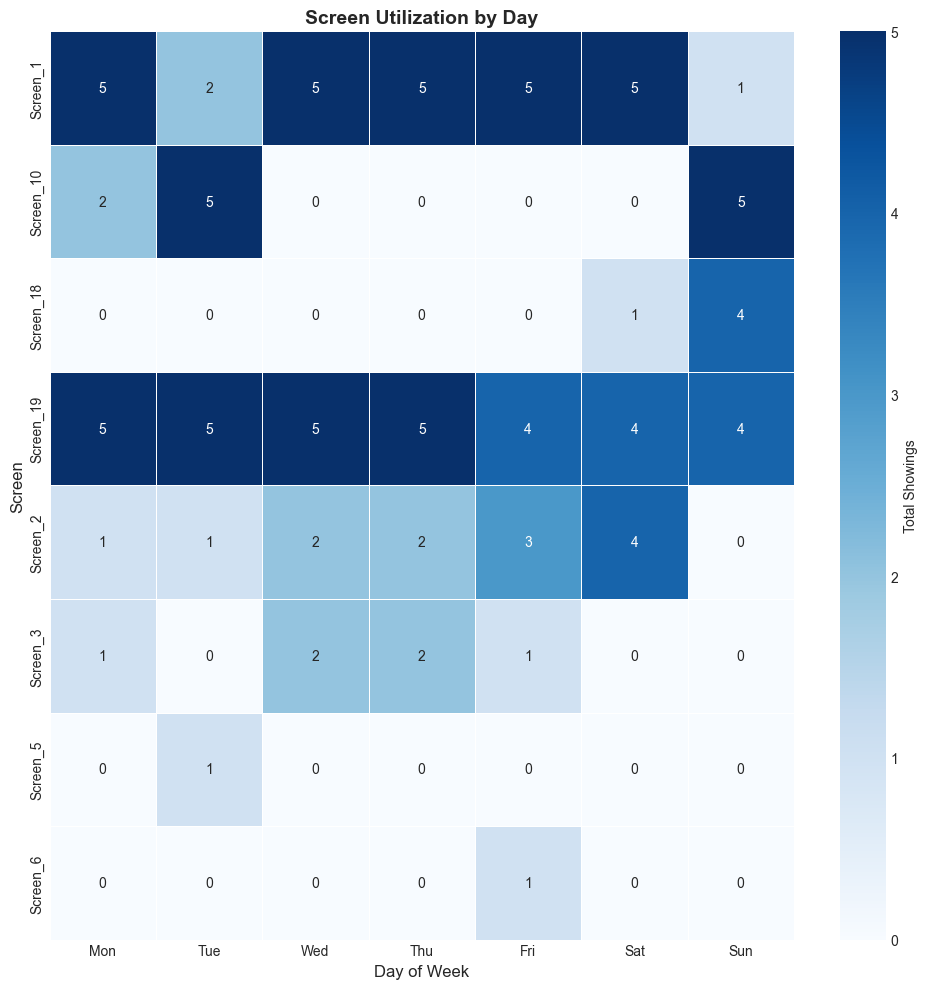


Screen Utilization Summary:
Total screens available: 19
Screens used: 8
Most utilized screen: Screen_19 (32 showings)
Least utilized screen: Screen_5 (1 showings)


In [38]:
# Screen utilization by day
screen_pivot = schedule_df.pivot_table(
    index='screen',
    columns='day',
    values='showings',
    aggfunc='sum',
    fill_value=0
)

screen_pivot = screen_pivot[day_order]

plt.figure(figsize=(10, 10))
sns.heatmap(
    screen_pivot, 
    annot=True, 
    fmt='.0f', 
    cmap='Blues', 
    cbar_kws={'label': 'Total Showings'},
    linewidths=0.5
)
plt.title('Screen Utilization by Day', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Screen', fontsize=12)
plt.tight_layout()
plt.show()

# Summary stats
print("\nScreen Utilization Summary:")
print(f"Total screens available: 19")
print(f"Screens used: {len(schedule_df['screen'].unique())}")
print(f"Most utilized screen: {screen_pivot.sum(axis=1).idxmax()} ({screen_pivot.sum(axis=1).max():.0f} showings)")
print(f"Least utilized screen: {screen_pivot.sum(axis=1).idxmin()} ({screen_pivot.sum(axis=1).min():.0f} showings)")

## 3. Demand vs. Realized Analysis

In [39]:
# Merge demand and realized
demand_realized = demand_df.merge(
    realized_df[['movie_id', 'day', 'realized_tickets', 'scheduled_flag']],
    on=['movie_id', 'day'],
    how='left'
)

demand_realized['fulfillment_rate'] = (
    demand_realized['realized_tickets'] / demand_realized['demand']
).fillna(0)

demand_realized.head(10)

,movie_id,day,demand,realized_tickets,scheduled_flag,fulfillment_rate
0,3664,Mon,176.978,129.726220,1,0.733008
1,3664,Tue,176.978,129.726220,1,0.733008
2,3664,Wed,199.100,145.941814,1,0.733008
3,3664,Thu,221.222,162.157408,1,0.733008
4,3664,Fri,287.588,210.804191,1,0.733008
5,3664,Sat,353.956,259.452440,1,0.733008
6,3664,Sun,353.956,259.452440,1,0.733008
7,3488,Mon,130.958,95.993210,1,0.733008
8,3488,Tue,130.958,95.993210,1,0.733008
9,3488,Wed,147.326,107.991078,1,0.733008


In [40]:
# Calculate key metrics
total_demand = demand_realized['demand'].sum()
total_realized = demand_realized['realized_tickets'].sum()
overall_fulfillment = total_realized / total_demand

print("\n" + "="*50)
print("DEMAND FULFILLMENT ANALYSIS")
print("="*50)
print(f"Total Demand (tickets):        {total_demand:,.0f}")
print(f"Total Realized (tickets):      {total_realized:,.0f}")
print(f"Overall Fulfillment Rate:      {overall_fulfillment:.1%}")
print(f"Unfulfilled Demand:            {total_demand - total_realized:,.0f} tickets")


DEMAND FULFILLMENT ANALYSIS
Total Demand (tickets):        8,343
Total Realized (tickets):      6,116
Overall Fulfillment Rate:      73.3%
Unfulfilled Demand:            2,228 tickets


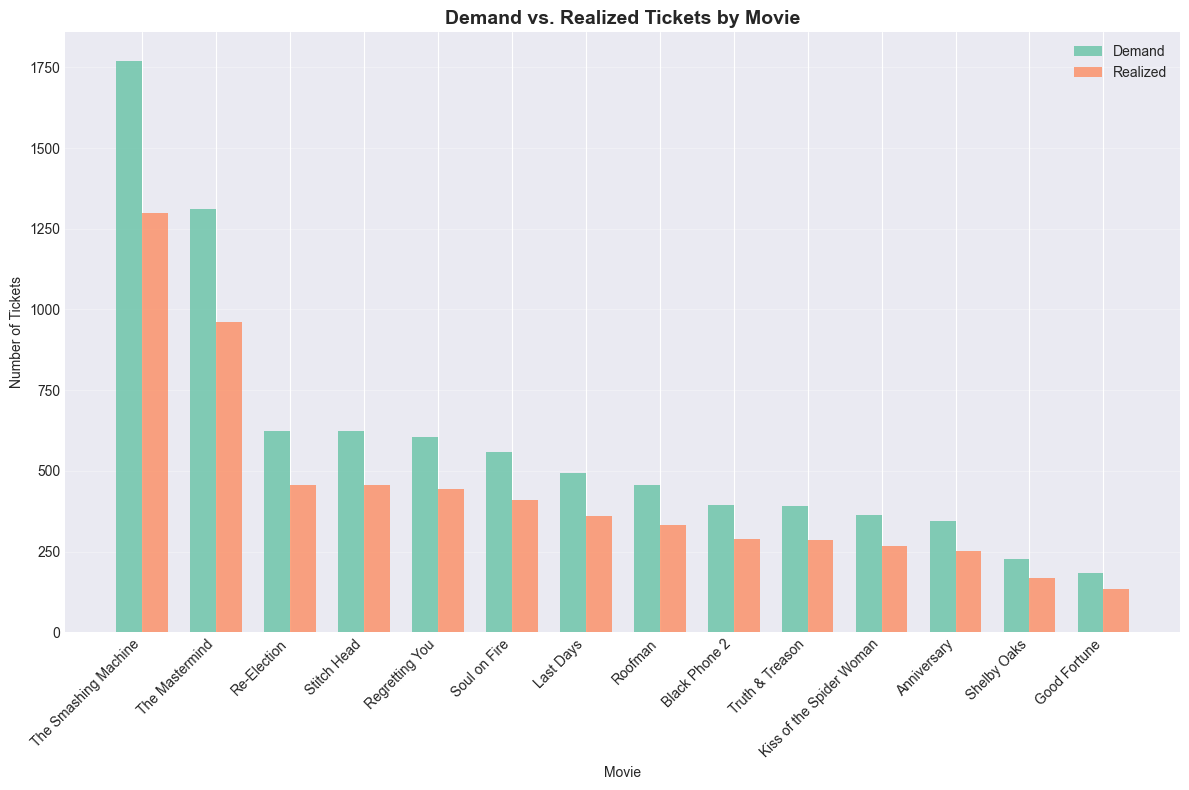

In [41]:
# Demand fulfillment by movie
movie_fulfillment = demand_realized.groupby('movie_id').agg({
    'demand': 'sum',
    'realized_tickets': 'sum'
}).reset_index()

movie_fulfillment['fulfillment_rate'] = (
    movie_fulfillment['realized_tickets'] / movie_fulfillment['demand']
)

# Add movie titles
movie_fulfillment = movie_fulfillment.merge(
    movie_df[['movie_id', 'title']], 
    on='movie_id'
)

# Sort by demand
movie_fulfillment = movie_fulfillment.sort_values('demand', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(movie_fulfillment))
width = 0.35

bars1 = ax.bar(x - width/2, movie_fulfillment['demand'], width, label='Demand', alpha=0.8)
bars2 = ax.bar(x + width/2, movie_fulfillment['realized_tickets'], width, label='Realized', alpha=0.8)

ax.set_xlabel('Movie')
ax.set_ylabel('Number of Tickets')
ax.set_title('Demand vs. Realized Tickets by Movie', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(movie_fulfillment['title'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 3.1 Daily Demand Patterns

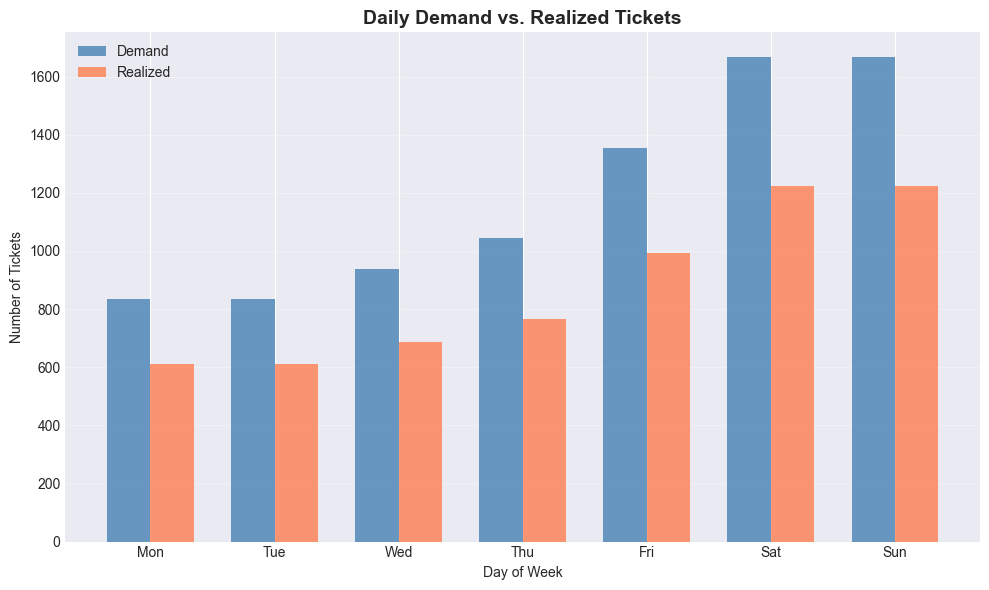

In [42]:
# Daily demand vs realized
daily_demand_realized = demand_realized.groupby('day').agg({
    'demand': 'sum',
    'realized_tickets': 'sum'
}).reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(day_order))
width = 0.35

ax.bar(x - width/2, daily_demand_realized['demand'], width, label='Demand', alpha=0.8, color='steelblue')
ax.bar(x + width/2, daily_demand_realized['realized_tickets'], width, label='Realized', alpha=0.8, color='coral')

ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Tickets')
ax.set_title('Daily Demand vs. Realized Tickets', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(day_order)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Revenue Analysis

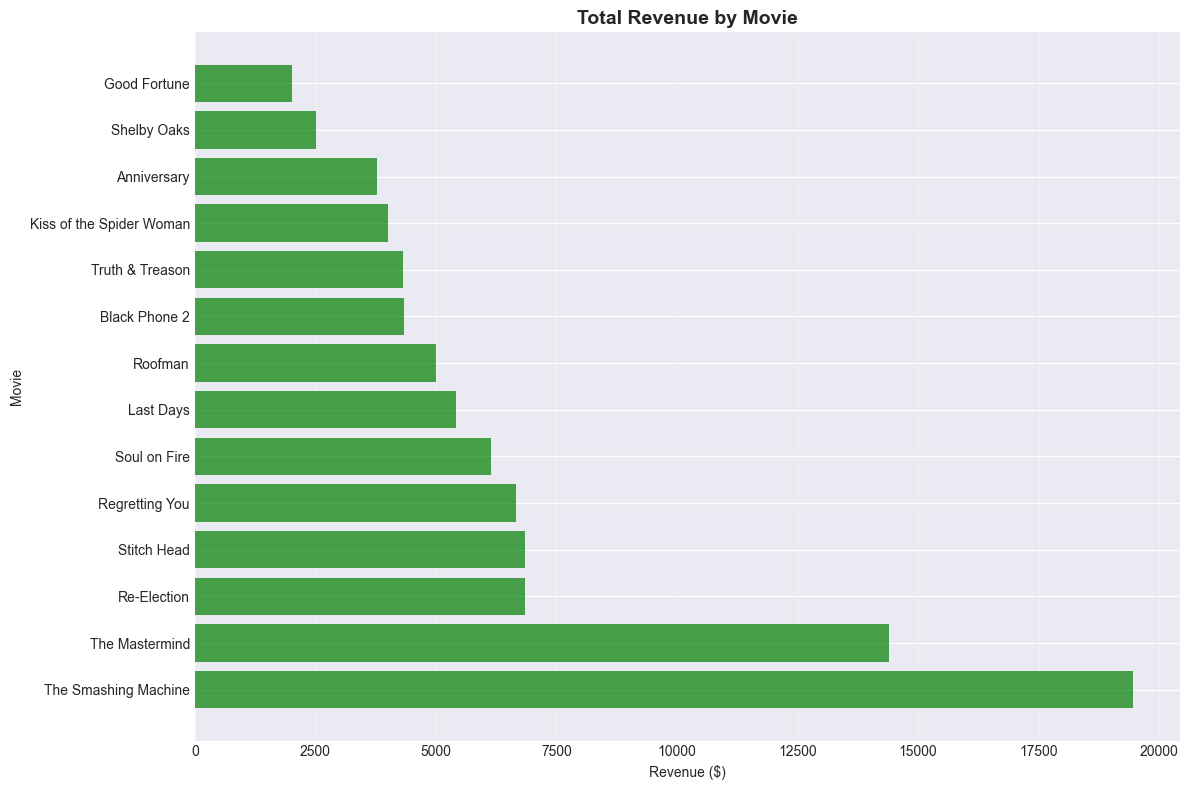


Top 5 Revenue Generating Movies:
1. The Smashing Machine                    : $19,458.91
2. The Mastermind                          : $14,398.94
3. Re-Election                             : $6,853.76
4. Stitch Head                             : $6,839.93
5. Regretting You                          : $6,651.45


In [43]:
# Calculate revenue by movie and day
# Assuming ticket price from parameters
ticket_price = 15.00  # Default if not in parameters

revenue_df = realized_df.copy()
revenue_df['revenue'] = revenue_df['realized_tickets'] * ticket_price

# Add movie titles
revenue_df = revenue_df.merge(
    movie_df[['movie_id', 'title']], 
    on='movie_id'
)

# Revenue by movie
movie_revenue = revenue_df.groupby('title')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(movie_revenue.index, movie_revenue.values, alpha=0.7, color='green')
plt.xlabel('Revenue ($)')
plt.ylabel('Movie')
plt.title('Total Revenue by Movie', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop 5 Revenue Generating Movies:")
for i, (movie, rev) in enumerate(movie_revenue.head().items(), 1):
    print(f"{i}. {movie:40s}: ${rev:,.2f}")

## 6. Capacity Analysis

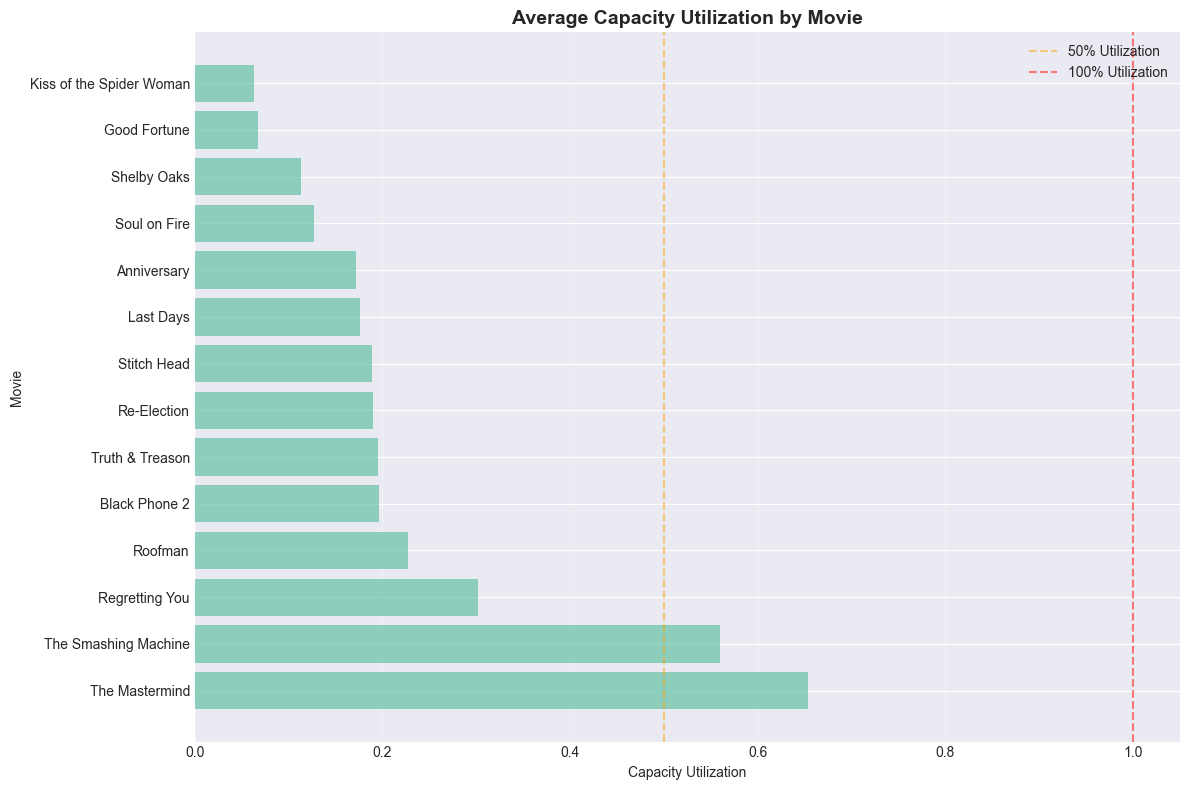

In [44]:
# Define screen capacities (from problem description)
screen_capacities = {
    f'Screen_{i}': 210 for i in range(1, 19)
}
screen_capacities['Screen_19'] = 600

# Merge schedule with realized tickets
schedule_realized = schedule_df.merge(
    realized_df[['movie_id', 'day', 'realized_tickets']],
    on=['movie_id', 'day'],
    how='left'
)

# Calculate capacity utilization per showing
schedule_realized['screen_capacity'] = schedule_realized['screen'].map(screen_capacities)
schedule_realized['total_capacity'] = schedule_realized['screen_capacity'] * schedule_realized['showings']
schedule_realized['utilization'] = schedule_realized['realized_tickets'] / schedule_realized['total_capacity']

# Add movie titles
schedule_realized = schedule_realized.merge(
    movie_df[['movie_id', 'title']], 
    on='movie_id'
)

# Average utilization by movie
movie_utilization = schedule_realized.groupby('title')['utilization'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
bars = plt.barh(movie_utilization.index, movie_utilization.values, alpha=0.7)
plt.xlabel('Capacity Utilization')
plt.ylabel('Movie')
plt.title('Average Capacity Utilization by Movie', fontsize=14, fontweight='bold')
plt.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='50% Utilization')
plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='100% Utilization')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Solution Quality Summary

In [ ]:
# Comprehensive summary
print("\n" + "="*70)
print("COMPREHENSIVE OPTIMIZATION ANALYSIS SUMMARY")
print("="*70)

print("\n1. FINANCIAL METRICS")
print("-" * 70)
print(f"   Total Revenue:                    ${summary_df.loc['total_revenue', 'value']:,.2f}")
print(f"   Total Tickets Sold:               {summary_df.loc['total_tickets_sold', 'value']:,.0f}")
print(f"   Average Revenue per Showing:      ${summary_df.loc['total_revenue', 'value'] / summary_df.loc['total_showings', 'value']:,.2f}")
print(f"   Average Tickets per Showing:      {summary_df.loc['avg_tickets_per_showing', 'value']:.1f}")

print("\n2. OPERATIONAL METRICS")
print("-" * 70)
print(f"   Total Showings:                   {summary_df.loc['total_showings', 'value']:.0f}")
print(f"   Movies Scheduled:                 {summary_df.loc['num_movies_scheduled', 'value']:.0f}")
print(f"   Screens Used:                     {summary_df.loc['num_screens_used', 'value']:.0f} / 19")
print(f"   Average Showings per Movie:       {summary_df.loc['avg_showings_per_movie', 'value']:.1f}")
print(f"   Capacity Utilization:             {summary_df.loc['capacity_utilization', 'value']:.1%}")

print("\n3. DEMAND FULFILLMENT")
print("-" * 70)
print(f"   Total Demand:                     {total_demand:,.0f} tickets")
print(f"   Total Realized:                   {total_realized:,.0f} tickets")
print(f"   Overall Fulfillment Rate:         {overall_fulfillment:.1%}")
print(f"   Unfulfilled Demand:               {total_demand - total_realized:,.0f} tickets")

print("\n4. VARIETY & DIVERSITY")
print("-" * 70)
print(f"   Average Genres per Day:           {np.mean(list(genre_counts.values())):.1f}")
print(f"   Minimum Genres per Day:           {min(genre_counts.values())}")
print(f"   Genre Constraint Met:             {all(c >= 5 for c in genre_counts.values())}")

print("\n5. TOP PERFORMERS")
print("-" * 70)
print(f"   Highest Revenue Movie:            {movie_revenue.index[0]}")
print(f"                                     ${movie_revenue.iloc[0]:,.2f}")
print(f"   Most Scheduled Movie:             {schedule_realized.groupby('title')['showings'].sum().idxmax()}")
print(f"                                     {schedule_realized.groupby('title')['showings'].sum().max():.0f} showings")

print("\n" + "="*70)


COMPREHENSIVE OPTIMIZATION ANALYSIS SUMMARY

1. FINANCIAL METRICS
----------------------------------------------------------------------
   Total Revenue:                    $91,732.85
   Total Tickets Sold:               6,116
   Average Revenue per Showing:      $936.05
   Average Tickets per Showing:      62.4

2. OPERATIONAL METRICS
----------------------------------------------------------------------
   Total Showings:                   98
   Movies Scheduled:                 98
   Screens Used:                     8 / 19
   Average Showings per Movie:       7.0
   Capacity Utilization:             29.7%

3. DEMAND FULFILLMENT
----------------------------------------------------------------------
   Total Demand:                     8,343 tickets
   Total Realized:                   6,116 tickets
   Overall Fulfillment Rate:         73.3%
   Unfulfilled Demand:               2,228 tickets

4. VARIETY & DIVERSITY
-------------------------------------------------------------------

## 8. Schedule Detail Table

In [32]:
# Create detailed schedule view
detailed_schedule = schedule_realized[[
    'title', 'day', 'screen', 'showings', 'realized_tickets', 
    'screen_capacity', 'total_capacity', 'utilization'
]].copy()

detailed_schedule['utilization'] = detailed_schedule['utilization'].apply(lambda x: f"{x:.1%}")
detailed_schedule = detailed_schedule.sort_values(['day', 'screen'])

print("\nDetailed Schedule (first 20 entries):")
detailed_schedule.head(20)


Detailed Schedule (first 20 entries):


,title,day,screen,showings,realized_tickets,screen_capacity,total_capacity,utilization
39,Regretting You,Fri,Screen_1,1,72.057580,210,210,34.3%
60,Roofman,Fri,Screen_1,1,54.239631,210,210,25.8%
67,Black Phone 2,Fri,Screen_1,1,46.953535,210,210,22.4%
74,Truth & Treason,Fri,Screen_1,1,46.682322,210,210,22.2%
95,Shelby Oaks,Fri,Screen_1,1,27.147670,210,210,12.9%
4,Eleanor the Great,Fri,Screen_19,1,117.281217,600,600,19.5%
11,The Smashing Machine,Fri,Screen_19,1,210.804191,600,600,35.1%
25,Re-Election,Fri,Screen_19,1,74.249272,600,600,12.4%
32,Stitch Head,Fri,Screen_19,1,74.099739,600,600,12.3%
46,Soul on Fire,Fri,Screen_19,1,66.604003,600,600,11.1%


## 9. Export Summary Report

In [33]:
# Export summary statistics to CSV
summary_report = pd.DataFrame({
    'Metric': [
        'Total Revenue',
        'Total Tickets Sold',
        'Total Showings',
        'Movies Scheduled',
        'Screens Used',
        'Capacity Utilization',
        'Demand Fulfillment Rate',
        'Average Genres per Day'
    ],
    'Value': [
        f"${summary_df.loc['total_revenue', 'value']:,.2f}",
        f"{summary_df.loc['total_tickets_sold', 'value']:,.0f}",
        f"{summary_df.loc['total_showings', 'value']:.0f}",
        f"{summary_df.loc['num_movies_scheduled', 'value']:.0f}",
        f"{summary_df.loc['num_screens_used', 'value']:.0f} / 19",
        f"{summary_df.loc['capacity_utilization', 'value']:.1%}",
        f"{overall_fulfillment:.1%}",
        f"{np.mean(list(genre_counts.values())):.1f}"
    ]
})

summary_report.to_csv(results_dir / 'analysis_summary.csv', index=False)
print("Summary report exported to: results/analysis_summary.csv")

summary_report

Summary report exported to: results/analysis_summary.csv


,Metric,Value
0,Total Revenue,"$104,047.38"
1,Total Tickets Sold,"6,936"
2,Total Showings,105
3,Movies Scheduled,105
4,Screens Used,11 / 19
5,Capacity Utilization,31.5%
6,Demand Fulfillment Rate,73.3%
7,Average Genres per Day,19.0
